In [1]:
import os
import sys
import dask
import zarr
import xesmf as xe
import numpy as np
import pandas as pd
import xarray as xr
from glob import glob

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
sys.path.insert(0, os.path.realpath('../libs/'))
import graph_utils as gu

In [16]:
year = 2070

In [17]:
if year % 4 == 0:
    N_day = 366
else:
    N_day = 365

In [18]:
# fn_365 = '/glade/campaign/ral/hap/ksha/DWC_data/CONUS_domain_GP/clim/CONUS_GP_clim_15d.zarr'
# ds = xr.open_zarr(fn_365)

fn_366 = '/glade/campaign/ral/hap/ksha/DWC_data/CONUS_domain_GP/clim/CONUS_GP_clim_30d_366.zarr'
ds = xr.open_zarr(fn_366)

In [19]:
start = np.datetime64(f'{year}-01-01T00', 'h')
stop  = np.datetime64(f'{year+1}-01-01T00', 'h')

# hourly grid, then upcast to nanosecond resolution
time_ref = np.arange(start, stop, dtype='datetime64[h]').astype('datetime64[ns]')

In [20]:
ds_init = ds.stack(time=("doy", "hour")).reset_index("time").isel(time=slice(31))
ds_init = ds_init.assign_coords(time=time_ref[:31]).transpose("time", "bottom_top", "south_north", "west_east", ...)
ds_init = ds_init.drop_vars(['doy', 'hour'])

In [21]:
save_name = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_GP/opt_init_ERA5/clim_ref/clim_{year}_15d.zarr'
ds_init.to_zarr(save_name, mode='w', consolidated=True, compute=True)

In [22]:
save_name

'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_GP/opt_init_ERA5/clim_ref/clim_2070_15d.zarr'

In [23]:
ds_test = xr.open_zarr(save_name)

In [24]:
ds_test

<xarray.Dataset>
Dimensions:                  (time: 31, south_north: 336, west_east: 336,
                              bottom_top: 12, pressure_approx: 12)
Coordinates:
  * bottom_top               (bottom_top) float32 0.0 1.0 2.0 ... 9.0 10.0 11.0
  * pressure_approx          (pressure_approx) float32 1e+03 946.0 ... 100.0
  * south_north              (south_north) float32 0.0 1.0 2.0 ... 334.0 335.0
  * time                     (time) datetime64[ns] 2070-01-01 ... 2070-01-02T...
  * west_east                (west_east) float32 0.0 1.0 2.0 ... 334.0 335.0
Data variables: (12/28)
    WRF_GLW                  (time, south_north, west_east) float32 dask.array<chunksize=(1, 336, 336), meta=np.ndarray>
    WRF_MSLP                 (time, south_north, west_east) float32 dask.array<chunksize=(1, 336, 336), meta=np.ndarray>
    WRF_OLR                  (time, south_north, west_east) float32 dask.array<chunksize=(1, 336, 336), meta=np.ndarray>
    WRF_P                    (time, bottom_top, south_north, west_east) float32 dask.array<chunksize=(1, 12, 336, 336), meta=np.ndarray>
    WRF_PWAT                 (time, south_north, west_east) float32 dask.array<chunksize=(1, 336, 336), meta=np.ndarray>
    WRF_PWAT_05              (time, south_north, west_east) float32 dask.array<chunksize=(1, 336, 336), meta=np.ndarray>
    ...                       ...
    WRF_Z                    (time, bottom_top, south_north, west_east) float32 dask.array<chunksize=(1, 12, 336, 336), meta=np.ndarray>
    WRF_evapor               (time, south_north, west_east) float32 dask.array<chunksize=(1, 336, 336), meta=np.ndarray>
    WRF_precip               (time, south_north, west_east) float32 dask.array<chunksize=(1, 336, 336), meta=np.ndarray>
    WRF_precip_025           (time, south_north, west_east) float32 dask.array<chunksize=(1, 336, 336), meta=np.ndarray>
    WRF_radar_composite      (time, south_north, west_east) float32 dask.array<chunksize=(1, 336, 336), meta=np.ndarray>
    WRF_radar_composite_025  (time, south_north, west_east) float32 dask.array<chunksize=(1, 336, 336), meta=np.ndarray>

In [26]:
WRF_T2 = ds_test['WRF_T2'].values

In [27]:
WRF_T2.shape

(31, 336, 336)

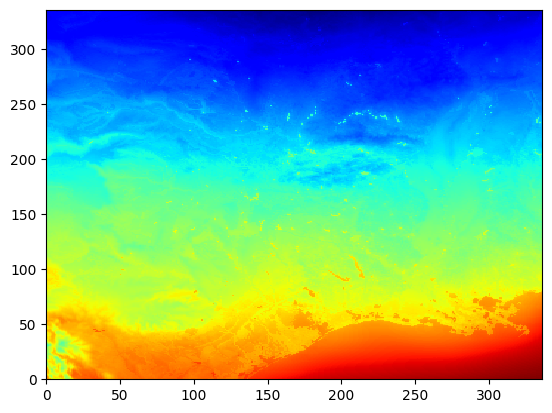

In [28]:
plt.pcolormesh(WRF_T2[0, ...], cmap=plt.cm.jet)